# Cost and Latency Modelling

In [1]:
import glob
import pandas as pd


models_of_interest = ["apertus-8b-instruct","apertus-70b-instruct"]

moi = models_of_interest[1]
# 1. Collect files
files = glob.glob("../../data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")


df_list = []
for file in files:
    temp_df = pd.read_parquet(file)
    temp_df = temp_df[temp_df["model"] == moi]
    temp_df = temp_df[temp_df["status"] == "success"]

    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# 2. Define the columns you want to KEEP
keep_cols = [
    "end_user",
    "startTime",
    "endTime",
    "completionStartTime",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
]

# Keep ONLY those (ignore missing if any file doesn't have it)
df = df[[c for c in keep_cols if c in df.columns]].copy()

# 3. Parse timestamps and sort
df["startTime"] = pd.to_datetime(df["startTime"],format = "mixed")
df = df.sort_values("startTime")

df["endTime"] = pd.to_datetime(df["endTime"],format = "mixed")
df["completionStartTime"] = pd.to_datetime(df["completionStartTime"],format = "mixed")
df["TTFT_latency"] = (df["completionStartTime"] - df["startTime"]).dt.total_seconds()
df["Decode_latency"] = (df["endTime"] - df["completionStartTime"]).dt.total_seconds()
df["latency"] = (df["endTime"] - df["startTime"]).dt.total_seconds()
# 4. Compute inter-arrival times (Δ between current and previous request)
df["interarrival_seconds"] = df["startTime"].diff().dt.total_seconds()


print(df.shape)
df.tail() ## no day is multiple times since it starts 02.09. and ends 01.10. so its exactly one month




(103729, 11)


,end_user,startTime,endTime,completionStartTime,prompt_tokens,completion_tokens,total_tokens,TTFT_latency,Decode_latency,latency,interarrival_seconds
103724,enduser_eb40d354,2025-10-01 03:27:12.190,2025-10-01 03:27:14.188,2025-10-01 03:27:12.363,773,86,859,0.173,1.825,1.998,63.785
103725,enduser_a22bfe8e,2025-10-01 03:31:09.197,2025-10-01 03:31:35.581,2025-10-01 03:31:09.371,785,1191,1976,0.174,26.210,26.384,237.007
103726,enduser_583ba19e,2025-10-01 03:31:44.785,2025-10-01 03:32:54.597,2025-10-01 03:31:45.109,1897,3052,4949,0.324,69.488,69.812,35.588
103727,enduser_d41d8cd9,2025-10-01 03:31:52.958,2025-10-01 03:32:04.954,2025-10-01 03:32:04.953,1216,537,1753,11.995,0.001,11.996,8.173
103728,enduser_d41d8cd9,2025-10-01 03:33:23.783,2025-10-01 03:33:34.514,2025-10-01 03:33:34.514,1119,500,1619,10.731,0.000,10.731,90.825


## Cost Analysis

In [2]:
import sys
import os

# Add the project root (parent of notebooks) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from configs.computation_config import * 
import json

cluster_cfgs = [ComputeCluster(**cfg) for cfg in json.load(open("../configs/cluster_configs.json","r"))["configurations"]]

Model A100_8x40GB_p4d_replica1 instantiated:
 - 1 replicas
 - Cluster price per hour: 32.77
Model A100_8x40GB_p4d_replica2 instantiated:
 - 2 replicas
 - Cluster price per hour: 64.00
Model A100_8x40GB_p4d_replica4 instantiated:
 - 4 replicas
 - Cluster price per hour: 126.00
Model H100_8x80GB_p5_replica1 instantiated:
 - 1 replicas
 - Cluster price per hour: 98.32
Model H100_8x80GB_p5_replica2 instantiated:
 - 2 replicas
 - Cluster price per hour: 196.00
Model H100_8x80GB_p5_replica4 instantiated:
 - 4 replicas
 - Cluster price per hour: 362.00


#### Cost Model
- We assume that there is a ratio of charging - we charge decode tokens $R$ times more than prefill tokens
so if we tahe total cost $C$, the cost per prefill token is $C/(prefill + R*decode)$
- We assume that there is $prefill\_R$ ratio of the prefill tokens out of all tokens, e.g. 0.7 - 70% of tokens are prefill - this is only for the idealistic costs

Let:

- $t\_ratio$ = fraction of **time allocated to producing prefill tokens**  
- $prefill\_R$ = fraction of total tokens we want to be **prefill**  

- $a$ = prefill token rate (tokens/time)  
- $b$ = decode token rate (tokens/time)  

The relationship is:

$$
\frac{t\_ratio \cdot a}{t\_ratio \cdot a + (1-t\_ratio) \cdot b} = prefill\_R
$$

Solve for $t\_ratio$:

$$
t\_ratio = \frac{prefill\_R \cdot b}{(1 - prefill\_R) \cdot a + prefill\_R \cdot b}
$$


In [3]:
R = 10  # given we do prefill tokens twice fast, they "could" be 10 times cheaper

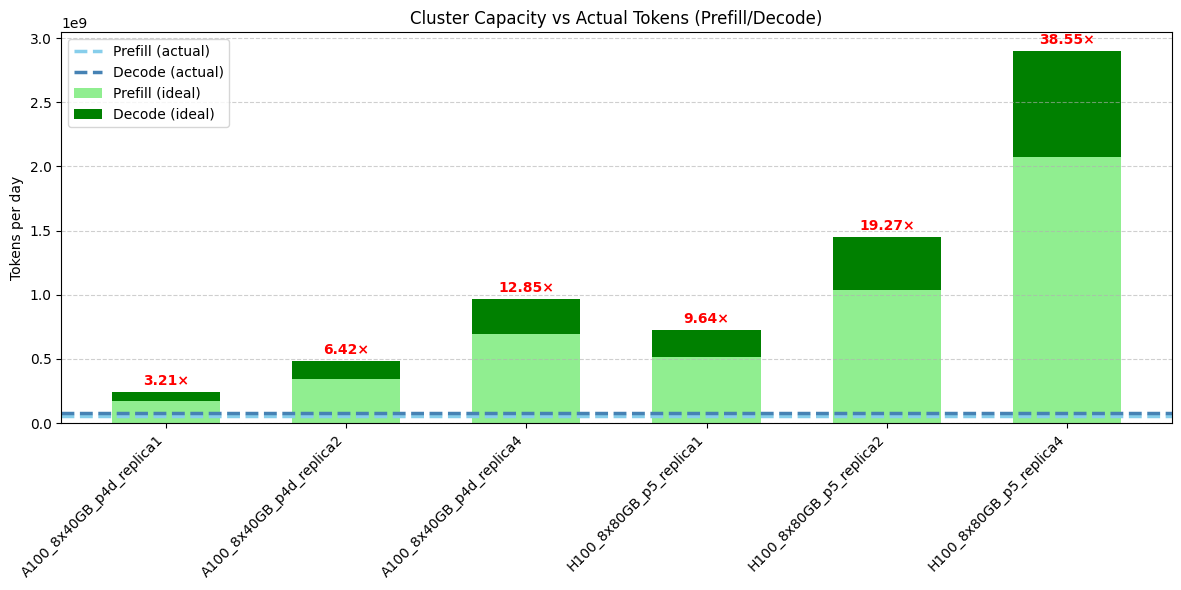

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Filtered data for the day
df_ = df[df["startTime"].dt.floor("D") == pd.Timestamp("2025-09-04")]

# Compute total actual tokens
total_prompt_tokens = df_["prompt_tokens"].sum()
total_completion_tokens = df_["completion_tokens"].sum()

prefill_R = total_prompt_tokens / (total_prompt_tokens + total_completion_tokens)

# Prepare arrays
actual_prefill = total_prompt_tokens
actual_decode = total_completion_tokens
actual_total = actual_prefill + actual_decode

ideal_tokens = []
for c in cluster_cfgs:
    ideal_pref_tks, ideal_dec_tks = c.peak_tks_per(days=1, prefill_R=prefill_R)
    ideal_tokens.append([ideal_pref_tks, ideal_dec_tks])
ideal_tokens = np.array(ideal_tokens)
ideal_total = ideal_tokens.sum(axis=1)

# Compute multipliers (how much more each cluster could handle)
multipliers = ideal_total / actual_total

# X-axis
cluster_names = [c.name for c in cluster_cfgs]
x = np.arange(len(cluster_names))
width = 0.6  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Plot stacked bars for cluster capacity
ax.bar(x, ideal_tokens[:,0], width, color='lightgreen', label='Prefill (ideal)')
ax.bar(x, ideal_tokens[:,1], width, bottom=ideal_tokens[:,0], color='green', label='Decode (ideal)')

# Overlay horizontal lines for actual usage
ax.axhline(y=actual_prefill, color='skyblue', linewidth=2.5, linestyle='--', label='Prefill (actual)')
ax.axhline(y=actual_prefill+actual_decode, color='steelblue', linewidth=2.5, linestyle='--', label='Decode (actual)')

# Annotate multipliers above each cluster bar
for i, mult in enumerate(multipliers):
    ax.text(x[i], ideal_total[i] + 0.01*ideal_total.max(), f'{mult:.2f}×', 
            ha='center', va='bottom', fontweight='bold', color='red')

# Labels
ax.set_ylabel("Tokens per day")
ax.set_xticks(x)
ax.set_xticklabels(cluster_names, rotation=45, ha='right')
ax.set_title("Cluster Capacity vs Actual Tokens (Prefill/Decode)")

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Legend
ax.legend()
plt.tight_layout()
plt.show()


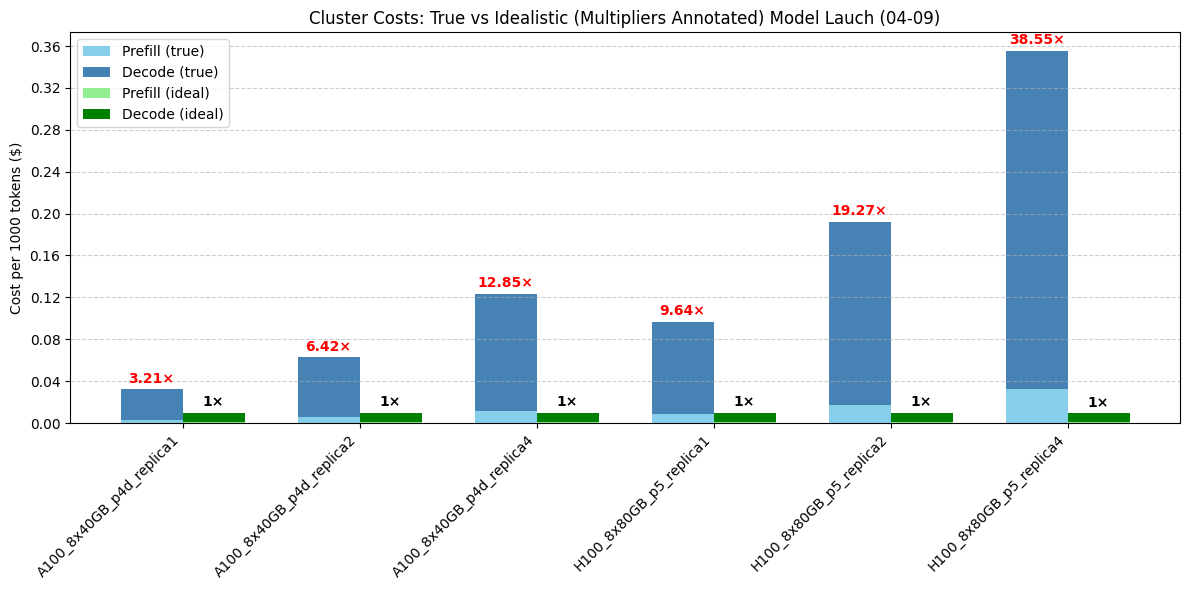

In [5]:
import matplotlib.pyplot as plt
import numpy as np




df_ = df[ df["startTime"].dt.floor("D") == pd.Timestamp("2025-09-04")]

# Compute actual and lowest prices
total_prompt_tokens = df_["prompt_tokens"].sum()  # 1 month
total_completion_tokens = df_["completion_tokens"].sum()  # 1 month

prefill_R = total_prompt_tokens / (total_prompt_tokens + total_completion_tokens)


true_price_per_tks = []
ideal_price_per_tks = []

for c in cluster_cfgs:
    ideal_pref_tks, ideal_dec_tks = c.peak_tks_per(days=1,prefill_R=prefill_R)

    
    # Actual price per token (using all tokens we need)
    total_price = c.price_per(days =1)

    true_prefill_price = total_price/(total_prompt_tokens + R*total_completion_tokens)

    ideal_prefill_price = total_price/(ideal_pref_tks + R*ideal_dec_tks)

    true_price_per_tks.append([true_prefill_price * 1000, true_prefill_price * R * 1000])
    ideal_price_per_tks.append([ideal_prefill_price * 1000, ideal_prefill_price * R * 1000])


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Example cluster names
cluster_names = [c.name for c in cluster_cfgs]

# Convert lists to NumPy arrays for easier stacking
true_prices = np.array(true_price_per_tks)
ideal_prices = np.array(ideal_price_per_tks)

x = np.arange(len(cluster_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

# True cost bars (left)
ax.bar(x - width/2, true_prices[:,0], width, label='Prefill (true)', color='skyblue')
ax.bar(x - width/2, true_prices[:,1], width, bottom=true_prices[:,0], label='Decode (true)', color='steelblue')

# Ideal cost bars (right)
ax.bar(x + width/2, ideal_prices[:,0], width, label='Prefill (ideal)', color='lightgreen')
ax.bar(x + width/2, ideal_prices[:,1], width, bottom=ideal_prices[:,0], label='Decode (ideal)', color='green')

# Compute total true vs ideal for multiplier annotation
total_true = true_prices.sum(axis=1)
total_ideal = ideal_prices.sum(axis=1)
multipliers = total_true / total_ideal

# Annotate multipliers above the bars
for i, mult in enumerate(multipliers):
    ax.text(x[i] - width/2, total_true[i] + 0.01*max(total_true.max(), total_ideal.max()), 
            f'{mult:.2f}×', ha='center', va='bottom', fontweight='bold', color='red')
    ax.text(x[i] + width/2, total_ideal[i] + 0.01*max(total_true.max(), total_ideal.max()), 
            '1×', ha='center', va='bottom', fontweight='bold', color='black')

# Labels and title
ax.set_ylabel("Cost per 1000 tokens ($)")
ax.set_xticks(x)
ax.set_xticklabels(cluster_names, rotation=45, ha='right')
ax.set_title("Cluster Costs: True vs Idealistic (Multipliers Annotated) Model Lauch (04-09)")

# Horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Increase number of y-ticks automatically
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))  # 10 ticks, adjust as needed

ax.legend()
plt.tight_layout()
plt.show()




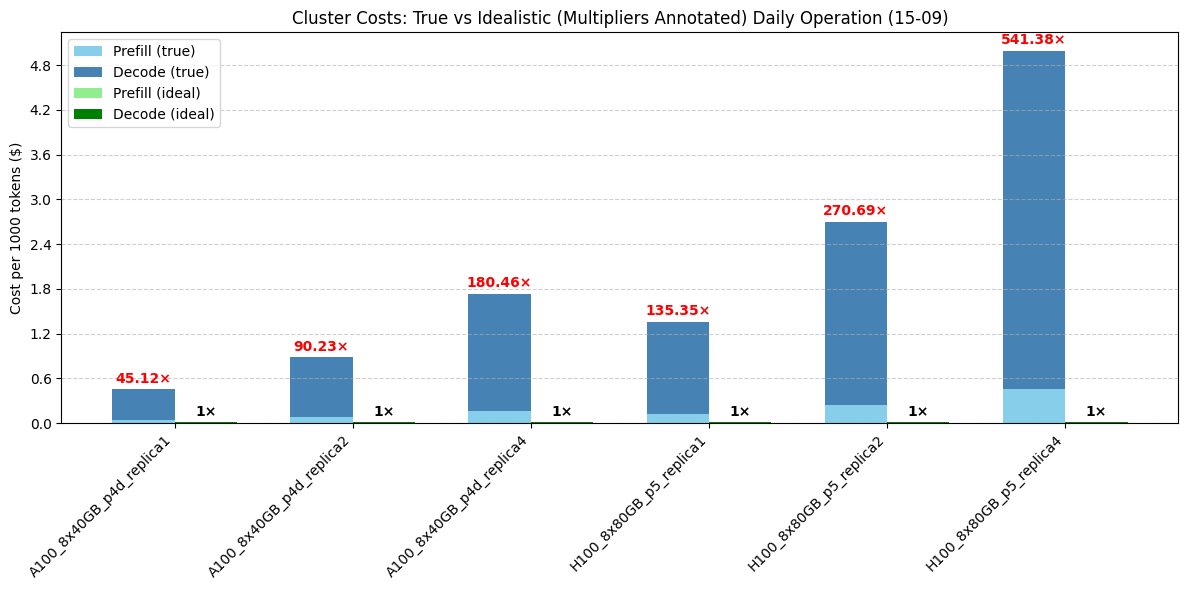

In [6]:
import matplotlib.pyplot as plt
import numpy as np


df_ = df[ df["startTime"].dt.floor("D") == pd.Timestamp("2025-09-15")]

# Compute actual and lowest prices
total_prompt_tokens = df_["prompt_tokens"].sum()  # 1 month
total_completion_tokens = df_["completion_tokens"].sum()  # 1 month

prefill_R = total_prompt_tokens / (total_prompt_tokens + total_completion_tokens)


true_price_per_tks = []
ideal_price_per_tks = []

for c in cluster_cfgs:
    ideal_pref_tks, ideal_dec_tks = c.peak_tks_per(days=1,prefill_R=prefill_R)
  
    
    # Actual price per token (using all tokens we need)
    total_price = c.price_per(days =1)

    true_prefill_price = total_price/(total_prompt_tokens + R*total_completion_tokens)

    ideal_prefill_price = total_price/(ideal_pref_tks + R*ideal_dec_tks)

    true_price_per_tks.append([true_prefill_price * 1000, true_prefill_price * R * 1000])
    ideal_price_per_tks.append([ideal_prefill_price * 1000, ideal_prefill_price * R * 1000])


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Example cluster names
cluster_names = [c.name for c in cluster_cfgs]

# Convert lists to NumPy arrays for easier stacking
true_prices = np.array(true_price_per_tks)
ideal_prices = np.array(ideal_price_per_tks)

x = np.arange(len(cluster_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

# True cost bars (left)
ax.bar(x - width/2, true_prices[:,0], width, label='Prefill (true)', color='skyblue')
ax.bar(x - width/2, true_prices[:,1], width, bottom=true_prices[:,0], label='Decode (true)', color='steelblue')

# Ideal cost bars (right)
ax.bar(x + width/2, ideal_prices[:,0], width, label='Prefill (ideal)', color='lightgreen')
ax.bar(x + width/2, ideal_prices[:,1], width, bottom=ideal_prices[:,0], label='Decode (ideal)', color='green')

# Compute total true vs ideal for multiplier annotation
total_true = true_prices.sum(axis=1)
total_ideal = ideal_prices.sum(axis=1)
multipliers = total_true / total_ideal

# Annotate multipliers above the bars
for i, mult in enumerate(multipliers):
    ax.text(x[i] - width/2, total_true[i] + 0.01*max(total_true.max(), total_ideal.max()), 
            f'{mult:.2f}×', ha='center', va='bottom', fontweight='bold', color='red')
    ax.text(x[i] + width/2, total_ideal[i] + 0.01*max(total_true.max(), total_ideal.max()), 
            '1×', ha='center', va='bottom', fontweight='bold', color='black')

# Labels and title
ax.set_ylabel("Cost per 1000 tokens ($)")
ax.set_xticks(x)
ax.set_xticklabels(cluster_names, rotation=45, ha='right')
ax.set_title("Cluster Costs: True vs Idealistic (Multipliers Annotated) Daily Operation (15-09)")

# Horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Increase number of y-ticks automatically
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))  # 10 ticks, adjust as needed

ax.legend()
plt.tight_layout()
plt.show()




#### API pricing

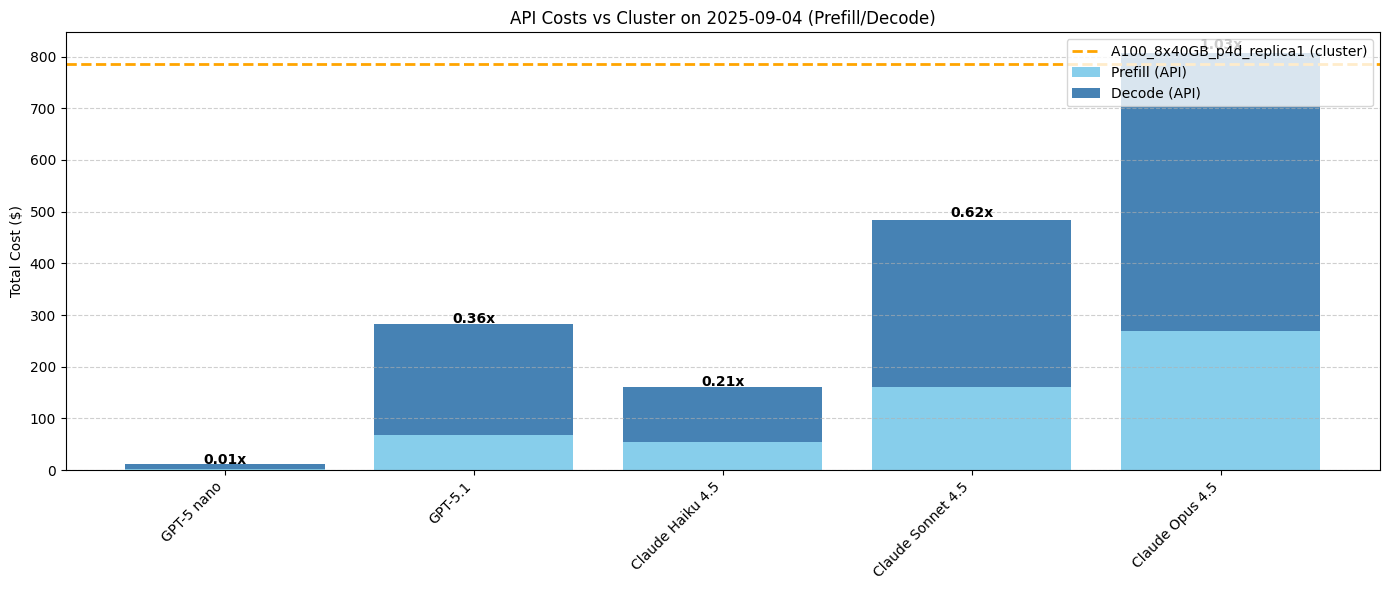

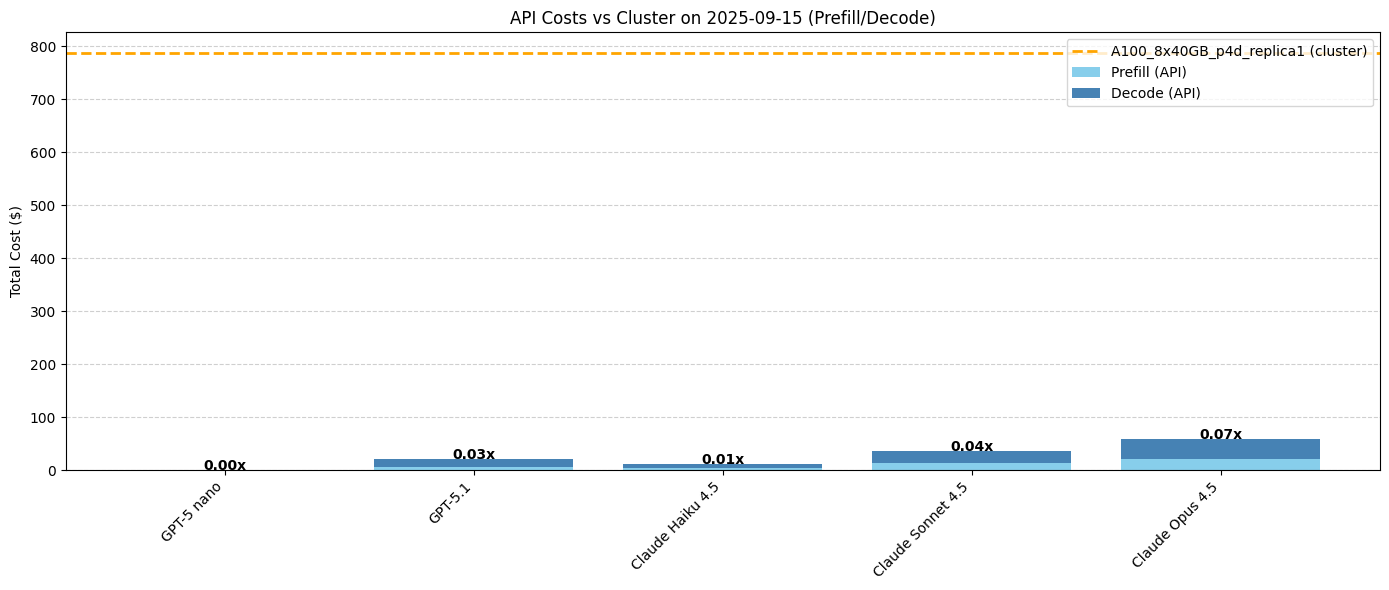

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Load API configs
with open("../configs/api_configs.json", "r") as f:
    data = json.load(f)["configurations"]

# Construct API objects
api_cfgs = [ComputeAPI(**cfg) for cfg in data]

AWS_EC2 = cluster_cfgs[0]  # first cluster for price comparison

# Days to plot
days_to_plot = ["2025-09-04", "2025-09-15"]

for day_str in days_to_plot:
    df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp(day_str)]
    
    # True total tokens from data
    total_prompt_tokens = df_day["prompt_tokens"].sum()
    total_completion_tokens = df_day["completion_tokens"].sum()
    
    # Compute API total costs using true tokens
    api_prefill_prices = []
    api_decode_prices = []
    api_names = []

    for api in api_cfgs:
        prefill_price = total_prompt_tokens * api.price_per_prefill_tkn
        decode_price = total_completion_tokens * api.price_per_decode_tkn
        api_prefill_prices.append(prefill_price)
        api_decode_prices.append(decode_price)
        api_names.append(api.name)

    # AWS total price (single value)
    true_total_price = AWS_EC2.price_per(days=1)
    
    # Plot
    x = np.arange(len(api_names))
    width = 0.8  # thicker bars

    fig, ax = plt.subplots(figsize=(14,6))

    # Stacked vertical bars for APIs
    ax.bar(x, api_prefill_prices, width, color='skyblue', label='Prefill (API)')
    ax.bar(x, api_decode_prices, width, bottom=api_prefill_prices, color='steelblue', label='Decode (API)')

    # Horizontal line for AWS cluster price
    ax.axhline(y=true_total_price, color='orange', linestyle='--', linewidth=2, label=f"{AWS_EC2.name} (cluster)")

    # Annotate multipliers
    for xi, prefill, decode in zip(x, api_prefill_prices, api_decode_prices):
        total = prefill + decode
        mult = total / true_total_price
        ax.text(xi, total*1.01, f"{mult:.2f}x", ha='center', fontsize=10, fontweight='bold')

    # Labels and styling
    ax.set_xticks(x)
    ax.set_xticklabels(api_names, rotation=45, ha='right')
    ax.set_ylabel("Total Cost ($)")
    ax.set_title(f"API Costs vs Cluster on {day_str} (Prefill/Decode)")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


### Latency
 - assume some batching, and i guess model the latency like that, or jsut average the per say hour tokens and compute time and divide
  - compute the analytical results assuming posson distribution for B (batch) requests incoming 

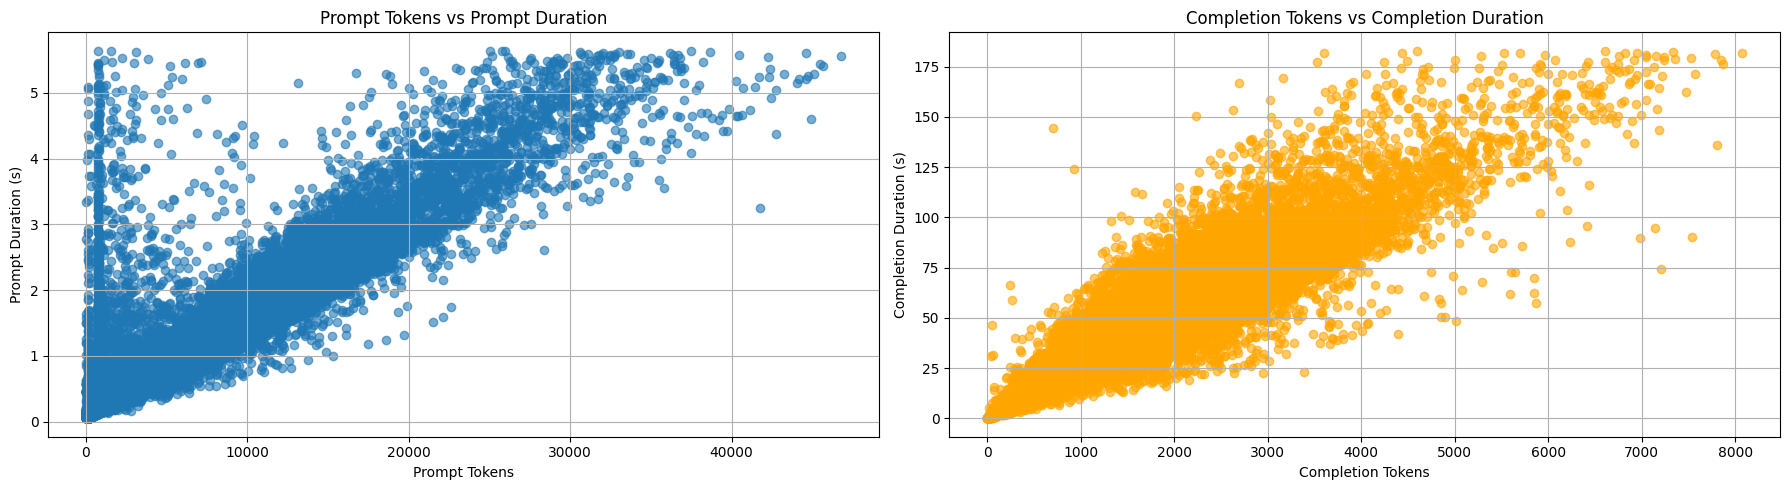

In [8]:
import matplotlib.pyplot as plt

# Compute durations


# Filter durations < 0.05s

df_filtered = df[(df["TTFT_latency"] >= 0.05) & (df["Decode_latency"] >= 0.05)].copy()

# Remove top 1% (99th percentile) of durations for each

prompt_upper = df_filtered["TTFT_latency"].quantile(0.98)
completion_upper = df_filtered["Decode_latency"].quantile(0.99)

df_filtered = df_filtered[
(df_filtered["TTFT_latency"] <= prompt_upper) &
(df_filtered["Decode_latency"] <= completion_upper)
]

# Create three scatter plots side by side

fig, axes = plt.subplots(1, 2, figsize=(18,5))

# Prompt tokens vs prompt duration

axes[0].scatter(df_filtered["prompt_tokens"], df_filtered["TTFT_latency"], alpha=0.6)
axes[0].set_xlabel("Prompt Tokens")
axes[0].set_ylabel("Prompt Duration (s)")
axes[0].set_title("Prompt Tokens vs Prompt Duration")
axes[0].grid(True)

# Completion tokens vs completion duration

axes[1].scatter(df_filtered["completion_tokens"], df_filtered["Decode_latency"], alpha=0.6, color="orange")
axes[1].set_xlabel("Completion Tokens")
axes[1].set_ylabel("Completion Duration (s)")
axes[1].set_title("Completion Tokens vs Completion Duration")
axes[1].grid(True)



plt.tight_layout()
plt.show()


In [86]:
import numpy as np
from datetime import timedelta


class ComputeSimulation:


    def __init__(self,cfg : ComputeSimulationCfg, labels = ["batchEndTime", "prefillTime", "decodeTime"]):

        self.cfg = cfg
        self.labels = labels

        
        

    def simulate(self,data : pd.DataFrame,start_time_ix, prompt_tks_ix, completion_tks_ix):
        ## our data must be sorted by the request time
        ## will always return completien times w.r.t the ordered dataset
        data= data.sort_values(by = data.columns[start_time_ix], ascending=True,inplace=False)
        a = data.to_numpy()
        dfs = []
        for cluster_cfg in self.cfg.cluster_cfgs:
            times = self.get_batch_times(a,start_time_ix,prompt_tks_ix,completion_tks_ix,cluster_cfg=cluster_cfg)
            df_ = pd.DataFrame(times, columns=self.labels)
            for col in self.labels:
                df_[col] = pd.to_datetime(df_[col]).dt.round("ms")

            dfs.append(df_)

        return dfs
    
    def get_batch_times(self,a,start_time_ix,prompt_tks_ix, completion_tks_ix, cluster_cfg : ComputeCluster):
        

        ## set the indices of the relevant stuff like start time
        start_time_ix = start_time_ix
        prompt_tks_ix = prompt_tks_ix
        comp_tks_ix = completion_tks_ix

        ## get the dimensions and params
        num_repl = cluster_cfg.num_replicas
        num_batch = self.cfg.batch_size
        peak_prefill_tks_per_sec_per_replica = cluster_cfg.peak_prefill_tks_per_sec_per_replica ## batching is done per replica
        peak_decode_tks_per_sec_per_replica = cluster_cfg.peak_decode_tks_per_sec_per_replica
        
        dyn_lim_sec = self.cfg.dynamic_lim_sec
        
        
        ## keep track of the last completion times of replica
        last_times_per_replica = np.full(num_repl, a[0,start_time_ix], dtype='object')
 
   
        batch_prefill_decode_times = []
        
        ## keep track of the currect batch
        ix = 0
        current_batch = [a[ix]]
        while(len(current_batch)) > 0:
            
            #print(current_batch)
            start_time = current_batch[0][start_time_ix]
            
     
            ## if its still withing constraints, we continue, also if we are at the end, we also must terminate and store stuff
            ix += 1
            if ix < len(a) and (a[ix][start_time_ix] - start_time).total_seconds() < dyn_lim_sec and len(current_batch) < num_batch:
                
                current_batch.append(a[ix])
                continue 
            else:
                possible_start_time = None
                if (len(current_batch) == num_batch or ix == len(a)):
                    possible_start_time = current_batch[-1][start_time_ix]

                else:
                    possible_start_time = start_time + pd.Timedelta(seconds=dyn_lim_sec)


                replica_ix = np.argmin([ts.value for ts in last_times_per_replica])## the replica that ends the earliest is the one who will process the batch
            
                
                actual_start_time = max(
                    possible_start_time,
                    pd.Timestamp(
                        ((last_times_per_replica[replica_ix].value))
                        )
                    )
                
  
                ## 1. End of Batch Fill Phase - when we can start processing
                batch_end_time = actual_start_time
                
                ## 2. Prefill Phase
                prefill_toks = float(sum(map(lambda x:x[prompt_tks_ix],current_batch))) 
                prefill_time_sec = prefill_toks/(peak_prefill_tks_per_sec_per_replica)

                batch_prefill_time = batch_end_time + pd.Timedelta(seconds=prefill_time_sec)

                ## 3. Decode Phase - thi should be handled so that it doesnt block if one is too big
                current_batch = sorted(current_batch,key=lambda x: x[comp_tks_ix])
                timedelta = 0  
                last_tks = 0
                decode_deltas = []

                for i, _ in enumerate(current_batch):
                    timedelta += (_[comp_tks_ix] - last_tks)*len(current_batch[i:]) / (peak_decode_tks_per_sec_per_replica*self.cfg.util_f(len(current_batch[i:]))) ## scale by the batch size
                    decode_deltas.append(timedelta)
                
            
                decode_times = [batch_end_time + pd.Timedelta(seconds=prefill_time_sec + decode_time_sec) for decode_time_sec in decode_deltas]


                ## make sure to remember until what time is this replica occupied
                
                ## we dont want to take the last delay because replcia can simoutaneously do other stuff - if it is no already saturated - lets do threshold //4 size of batch
                delay_time = actual_start_time + pd.Timedelta(seconds=prefill_time_sec + (decode_deltas[-2] if len(decode_times) > 1 else 0))
                last_times_per_replica[replica_ix] = delay_time
                
          
                for i in range(len(current_batch)):
                    batch_prefill_decode_times.append([batch_end_time,batch_prefill_time,decode_times[i]])

                current_batch = [] if ix == len(a) else [a[ix]]



        return batch_prefill_decode_times
    

    def get_batch(self,a,start_time_ix,ix, end_time = None):


        batch = []
        time = a[ix,start_time_ix]
        start_time = time

        while (end_time is None or  time <= end_time) and len(batch) < self.cfg.batch_size and (time - start_time).total_seconds() <= self.cfg.dynamic_lim_sec:
            
            batch.append(a[ix])

            ix += 1
            time - a[ix,start_time_ix]


        return batch, ix
    
    def get_batch_start_prefill_times(self,a, batch,start_time_ix,prompt_tks_ix, ix, root_time):

        possible_start_time = None
        if (len(batch) == self.cfg.batch_size or ix == len(a)):
            possible_start_time = batch[-1][start_time_ix]

        else:
            possible_start_time = batch[0][start_time_ix] + pd.Timedelta(seconds=self.cfg.dynamic_lim_sec)


        
        actual_start_time = max(
            possible_start_time,
            root_time
            )
        

        ## 1. End of Batch Fill Phase - when we can start processing
        batch_end_time = actual_start_time
        
        ## 2. Prefill Phase
        prefill_toks = float(sum(map(lambda x:x[prompt_tks_ix],batch))) 
        prefill_time_sec = prefill_toks/(self.cfg.peak_prefill_tks_per_sec_per_replica)

        batch_prefill_time = batch_end_time + pd.Timedelta(seconds=prefill_time_sec)

        return batch_end_time, batch_prefill_time



    def get_batch_times_ALT(self,a,start_time_ix,prompt_tks_ix, completion_tks_ix, cluster_cfg: ComputeCluster):

        peak_prefill_tks_per_sec_per_replica = cluster_cfg.peak_prefill_tks_per_sec_per_replica ## batching is done per replica
        peak_decode_tks_per_sec_per_replica = cluster_cfg.peak_decode_tks_per_sec_per_replica


        batch_beg_times = []
        batch_prefill_times = []
        batch_decode_times = []

        TODO_deltas = [0,0,0]

        batch = []
        queue = []
        for ix in range(len(a)):
            
            if len(queue) == 0: 
                queue.append(a[ix])
                continue
            
            
            diff_from_last = (a[ix,start_time_ix] - queue[-1][start_time_ix]).total_seconds()
            total_diff = (a[ix,start_time_ix] - queue[0][start_time_ix]).total_seconds()

            if (len(queue) >= self.cfg.batch_size or total_diff >= self.cfg.dynamic_lim_sec) and len(batch) < self.cfg.batch_size:

                batch.extend(queue[:min(self.cfg.batch_size - len(batch),len(queue))]) ## add to the batch
                
                queue = queue[min(self.cfg.batch_size - len(batch),len(queue)):]

                batch_beg_time, batch_prefill_time = self.get_batch_start_prefill_times(a,batch,start_time_ix,prompt_tks_ix,ix)

                
            else:
                pass

            queue.append(a[ix])
   


    def concat(self,df1,df2):

        return pd.concat([df1.reset_index(drop=True), df2.reset_index(drop=True)], axis=1)



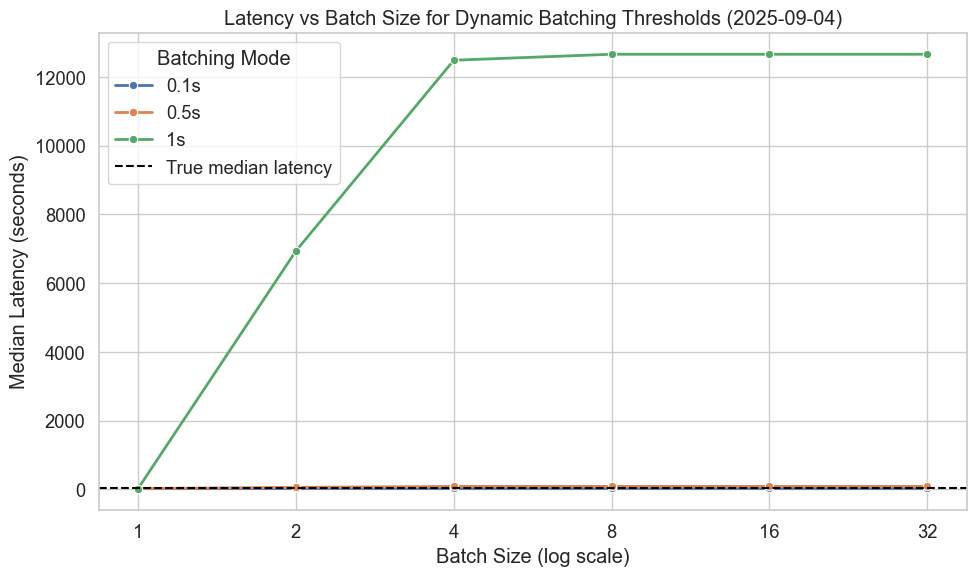

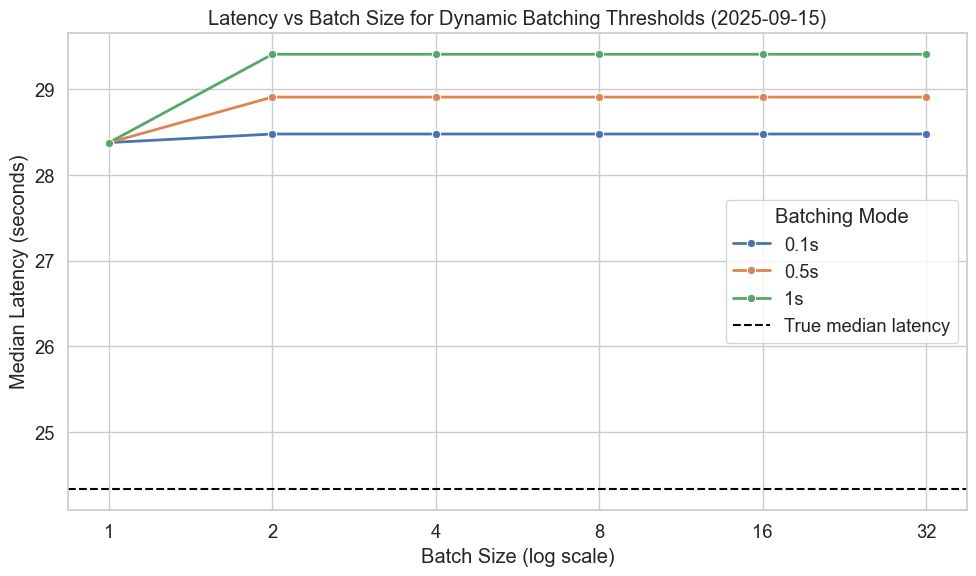

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Days to analyze
days = ["2025-09-04", "2025-09-15"]
CLUSTER = cluster_cfgs[0]

# Batching wait thresholds (None = static batching)
wait_configs = {
    "0.1s": 0.1,
    "0.5s": 0.5,
    "1s": 1,
}

batch_sizes = [1,2,4, 8, 16, 32]

# Utilization function (example)
util_f = lambda b: min(1,b/16.0)

for day in days:
    df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp(day)]
    all_results = []

    for label, wait_time in wait_configs.items():
        mode_results = []

        for bsize in batch_sizes:
            cfg = ComputeSimulationCfg("dddd",batch_size=bsize,dynamic_lim_sec=wait_time,cluster_cfgs=[CLUSTER],util_f=lambda b: min(1,b/25.0))
            
            b_algo = ComputeSimulation(cfg)

            # Compute estimated end times
            df_est = b_algo.simulate(df_day, 1, 4, 5)[0]
            df_f = pd.concat([df_day.reset_index(drop=True), df_est.reset_index(drop=True)], axis=1)
            df_f["latency_est"] = (df_f["decodeTime"] - df_f["startTime"]).dt.total_seconds()

            # Median latency
            mode_results.append({
                "batch_size": bsize,
                "median_latency": df_f["latency_est"].median(),
                "mode": label
            })

        all_results.extend(mode_results)

    # Combine all results
    plot_df = pd.DataFrame(all_results)

    # True latency baseline (median)
    median_interarrival = df_day[
        (df_day["latency"] >= 0.01) & (df_day["latency"] <= 4000)
    ]["latency"].median()

    # -------- Plot --------
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=plot_df,
        x="batch_size",
        y="median_latency",
        hue="mode",
        marker="o",
        linewidth=2
    )

    plt.axhline(median_interarrival, color="black", linestyle="--", label="True median latency")
    plt.xscale("log")
    plt.xticks(batch_sizes, batch_sizes)
    plt.xlabel("Batch Size (log scale)")
    plt.ylabel("Median Latency (seconds)")
    plt.title(f"Latency vs Batch Size for Dynamic Batching Thresholds ({day})")
    plt.legend(title="Batching Mode")
    plt.tight_layout()
    plt.show()


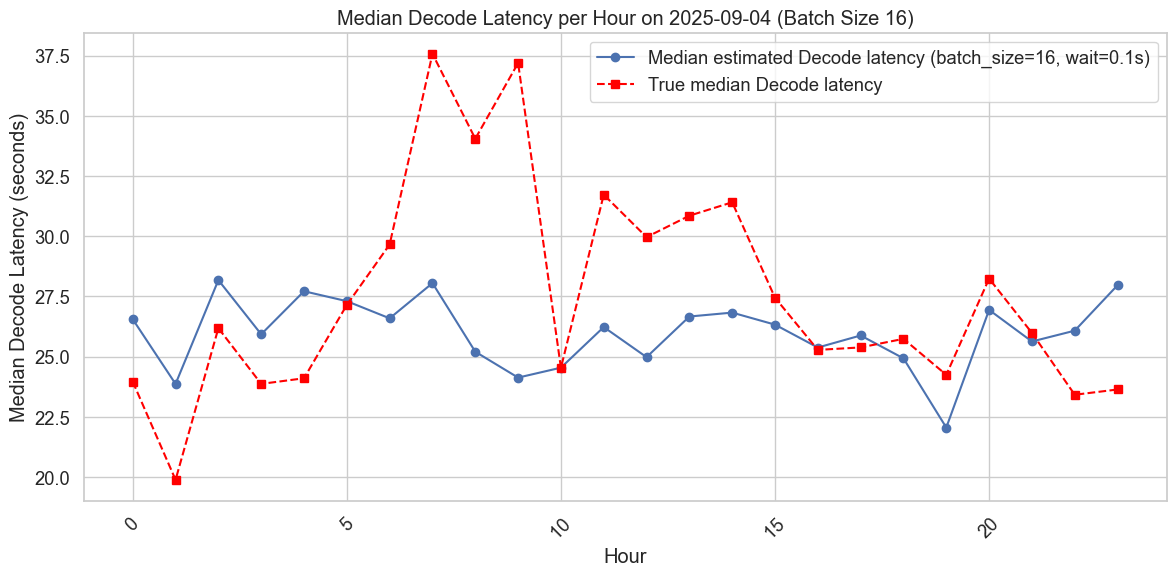

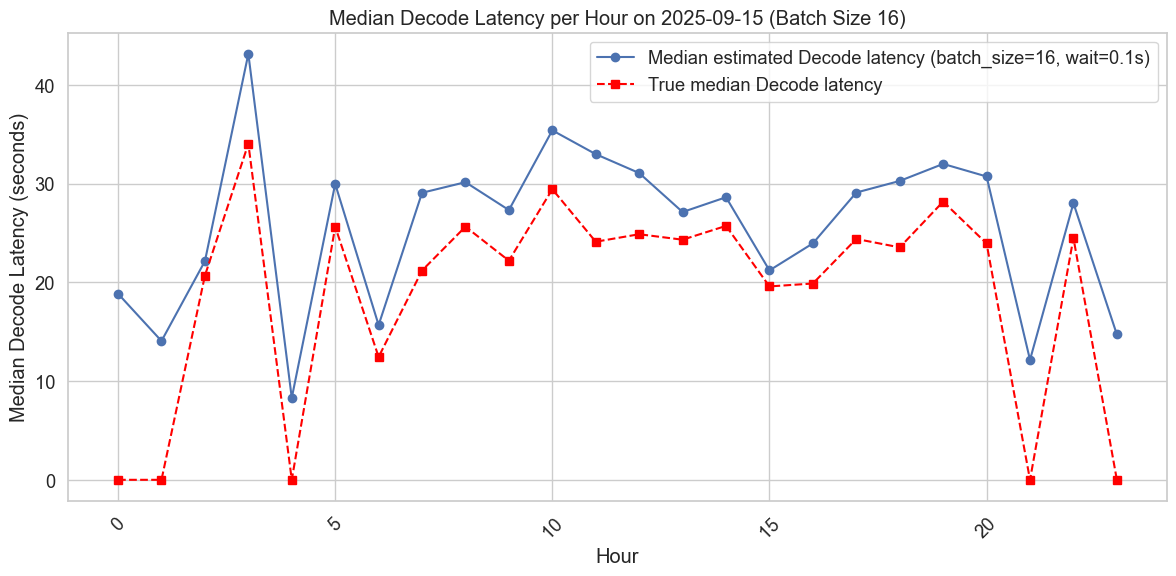

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




#util_f = lambda b: 0.05 + 0.9*(1/(1 + np.exp(-b+4)))


days_to_plot = ["2025-09-04", "2025-09-15"]

for day in days_to_plot:
    df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp(day)]

    # --- Batching setup ---
 
    cfg = ComputeSimulationCfg("dddd",batch_size=16,dynamic_lim_sec=0.1,cluster_cfgs=[CLUSTER],util_f=lambda b: 0.04)

    b_algo = ComputeSimulation(cfg)

    # Compute estimated end times
    df_est = b_algo.simulate(df_day, 1, 4, 5)[0]

    df_f = pd.concat([df_day.reset_index(drop=True), df_est.reset_index(drop=True)], axis=1)
    df_f["hour"] = df_f["startTime"].dt.hour
    df_f["latency_est"] = (df_f["decodeTime"] - df_f["prefillTime"]).dt.total_seconds()

    # --- Aggregate median estimated latency per hour ---
    median_est_per_hour = df_f.groupby("hour")["latency_est"].median().reset_index()

    # --- Aggregate true median latency per hour ---
    median_true_per_hour = df_f.groupby("hour")["Decode_latency"].median().reset_index()

    # --- Plot ---
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(12, 6))

    plt.plot(
        median_est_per_hour["hour"], 
        median_est_per_hour["latency_est"], 
        marker="o", 
        label=f"Median estimated Decode latency (batch_size=16, wait=0.1s)"
    )

    plt.plot(
        median_true_per_hour["hour"],
        median_true_per_hour["Decode_latency"],
        marker="s",
        color="red",
        linestyle="--",
        label="True median Decode latency"
    )


    plt.xlabel("Hour")
    plt.ylabel("Median Decode Latency (seconds)")
    plt.title(f"Median Decode Latency per Hour on {day} (Batch Size 16)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


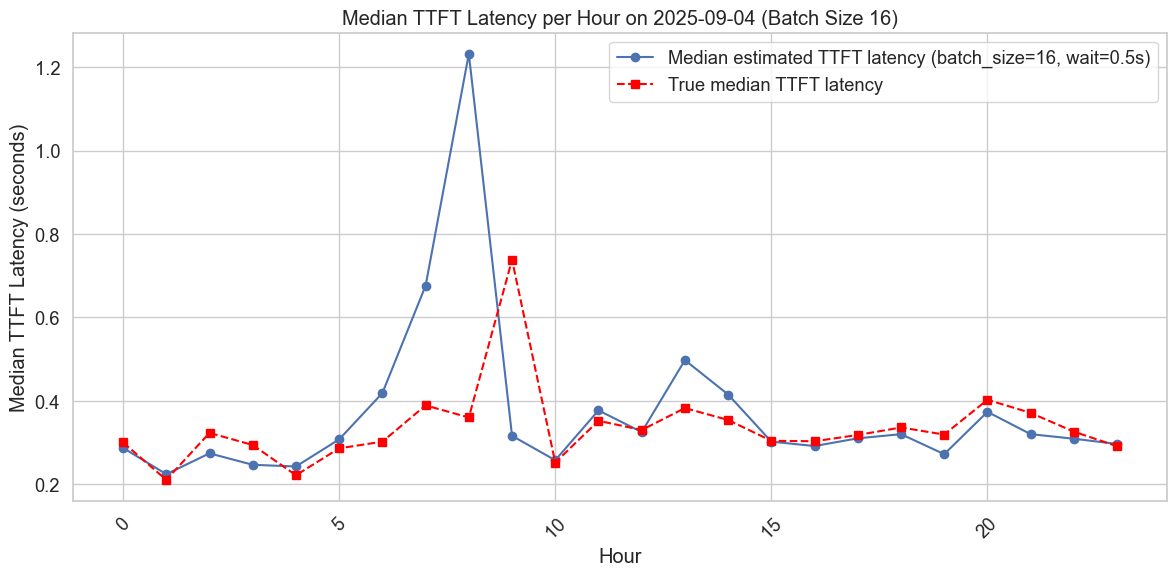

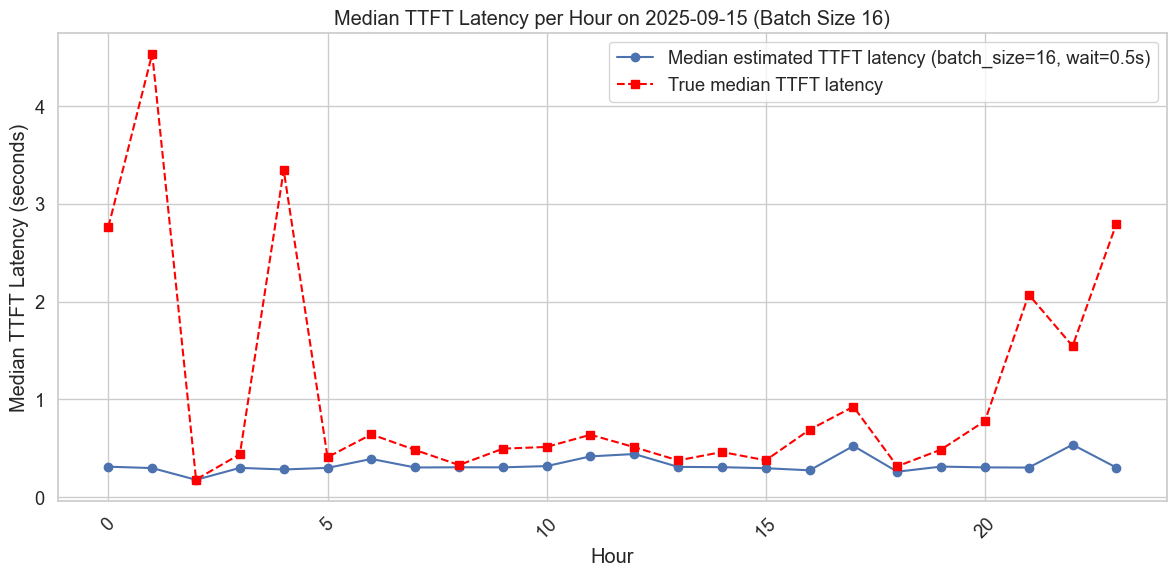

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




days_to_plot = ["2025-09-04", "2025-09-15"]

for day in days_to_plot:
    df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp(day)]


 
    cfg = ComputeSimulationCfg("dddd",batch_size=16,dynamic_lim_sec=0.1,cluster_cfgs=[CLUSTER],util_f=lambda b: min(1,b/25.0))
    
    b_algo = ComputeSimulation(cfg)

    # Compute estimated end times
    df_est = b_algo.simulate(df_day, 1, 4, 5)[0]


    df_f = pd.concat([df_day.reset_index(drop=True), df_est.reset_index(drop=True)], axis=1)
    df_f["hour"] = df_f["startTime"].dt.hour
    df_f["latency_est"] = (df_f["prefillTime"] - df_f["startTime"]).dt.total_seconds()

    # --- Aggregate median estimated latency per hour ---
    median_est_per_hour = df_f.groupby("hour")["latency_est"].quantile(0.5).reset_index()

    # --- Aggregate true median latency per hour ---
    median_true_per_hour = df_f.groupby("hour")["TTFT_latency"].quantile(0.5).reset_index()

    # --- Plot ---
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(12, 6))

    plt.plot(
        median_est_per_hour["hour"], 
        median_est_per_hour["latency_est"], 
        marker="o", 
        label=f"Median estimated TTFT latency (batch_size=16, wait=0.5s)"
    )

    plt.plot(
        median_true_per_hour["hour"],
        median_true_per_hour["TTFT_latency"],
        marker="s",
        color="red",
        linestyle="--",
        label="True median TTFT latency"
    )

    plt.xlabel("Hour")
    plt.ylabel("Median TTFT Latency (seconds)")
    plt.title(f"Median TTFT Latency per Hour on {day} (Batch Size 16)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Cost VS Latency


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



days_to_plot = ["2025-09-04", "2025-09-15"]

df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp(days_to_plot[0])]


# Compute estimated end times


# Compute estimated end times


prompt_tks=  df_day["prompt_tokens"].sum()
comp_tks=  df_day["completion_tokens"].sum()
df_f["TTFT_latency"]


R = 10 # we charge 10 times more for completion tokens
Q = 0.5
prices=  []
latencies = []
req_per_sec = []
for cfg in cluster_cfgs:
     # --- Batching setup ---
    
    c_cfg = ComputeSimulationCfg("333",batch_size=16,dynamic_lim_sec=0.1,util_f=lambda b: min(1,b/25.0), cluster_cfgs=[cfg])

    b_algo = ComputeSimulation(c_cfg)

    df_est = b_algo.simulate(df_day, 1, 4, 5)[0]

    cost = cfg.price_per(days=1)

    df_f = pd.concat([df_day.reset_index(drop=True), df_est.reset_index(drop=True)], axis=1)

    df_f["TTFT_latency_est"] = (df_f["prefillTime"] - df_f["startTime"]).dt.total_seconds()

    median_latency_per_1K = 1e3 * (df_f["TTFT_latency_est"] / df_f["prompt_tokens"]).quantile(Q)

    prefill_tk_price = cfg.price_per(days=1)/(R * comp_tks + prompt_tks)

    df_f['latency_est'] = (df_f["decodeTime"] - df_f["startTime"]).dt.total_seconds()

    req_per_sec_ = len(df_f)/ df_f['latency_est'].sum()
    prefill_price_1K = prefill_tk_price*1e3
    decode_price_1K = prefill_tk_price*1e3*R

    latencies.append(median_latency_per_1K)
    prices.append([prefill_price_1K,decode_price_1K])
    req_per_sec.append(req_per_sec_)

true_prefill_price_1K = prices[0][0]
true_decode_price_1K = prices[0][1]

true_median_latency_per_1K = 1e3 *(df_f["TTFT_latency"]/ df_f["prompt_tokens"]).quantile(Q)


In [90]:



print("True Requests per Sec. : ", len(df_f)/ df_f["latency"].sum())
print("Estimate Requests per Sec. : ", req_per_sec)


True Requests per Sec. :  0.03611363840574491
Estimate Requests per Sec. :  [np.float64(0.0352067989697084), np.float64(0.03907438342302254), np.float64(0.03926822050996833), np.float64(0.11391921915807421), np.float64(0.11684940840705423), np.float64(0.11690240956942428)]


In [15]:
df_f.head()

,end_user,startTime,endTime,completionStartTime,prompt_tokens,completion_tokens,total_tokens,TTFT_latency,Decode_latency,latency,interarrival_seconds,batchEndTime,prefillTime,decodeTime,TTFT_latency_est,latency_est
0,enduser_1603b034,2025-09-03 00:01:08.479,2025-09-03 00:01:12.768,2025-09-03 00:01:08.583,456,216,672,0.104,4.185,4.289,173.811,2025-09-03 00:01:08.579,2025-09-03 00:01:08.594,2025-09-03 00:01:10.394,0.115,1.915
1,enduser_735a7b67,2025-09-03 00:01:17.417,2025-09-03 00:02:40.483,2025-09-03 00:01:18.797,10409,3558,13967,1.380,81.686,83.066,8.938,2025-09-03 00:01:17.517,2025-09-03 00:01:17.864,2025-09-03 00:01:47.514,0.447,30.097
2,enduser_c24523a2,2025-09-03 00:02:37.901,2025-09-03 00:02:40.767,2025-09-03 00:02:38.770,6863,100,6963,0.869,1.997,2.866,80.484,2025-09-03 00:02:38.001,2025-09-03 00:02:38.230,2025-09-03 00:02:39.063,0.329,1.162
3,enduser_1603b034,2025-09-03 00:02:46.768,2025-09-03 00:02:50.761,2025-09-03 00:02:46.911,732,180,912,0.143,3.850,3.993,8.867,2025-09-03 00:02:46.868,2025-09-03 00:02:46.892,2025-09-03 00:02:48.392,0.124,1.624
4,enduser_48b34da3,2025-09-03 00:03:02.168,2025-09-03 00:03:02.484,2025-09-03 00:03:02.227,129,12,141,0.059,0.257,0.316,15.400,2025-09-03 00:03:02.268,2025-09-03 00:03:02.272,2025-09-03 00:03:02.372,0.104,0.204


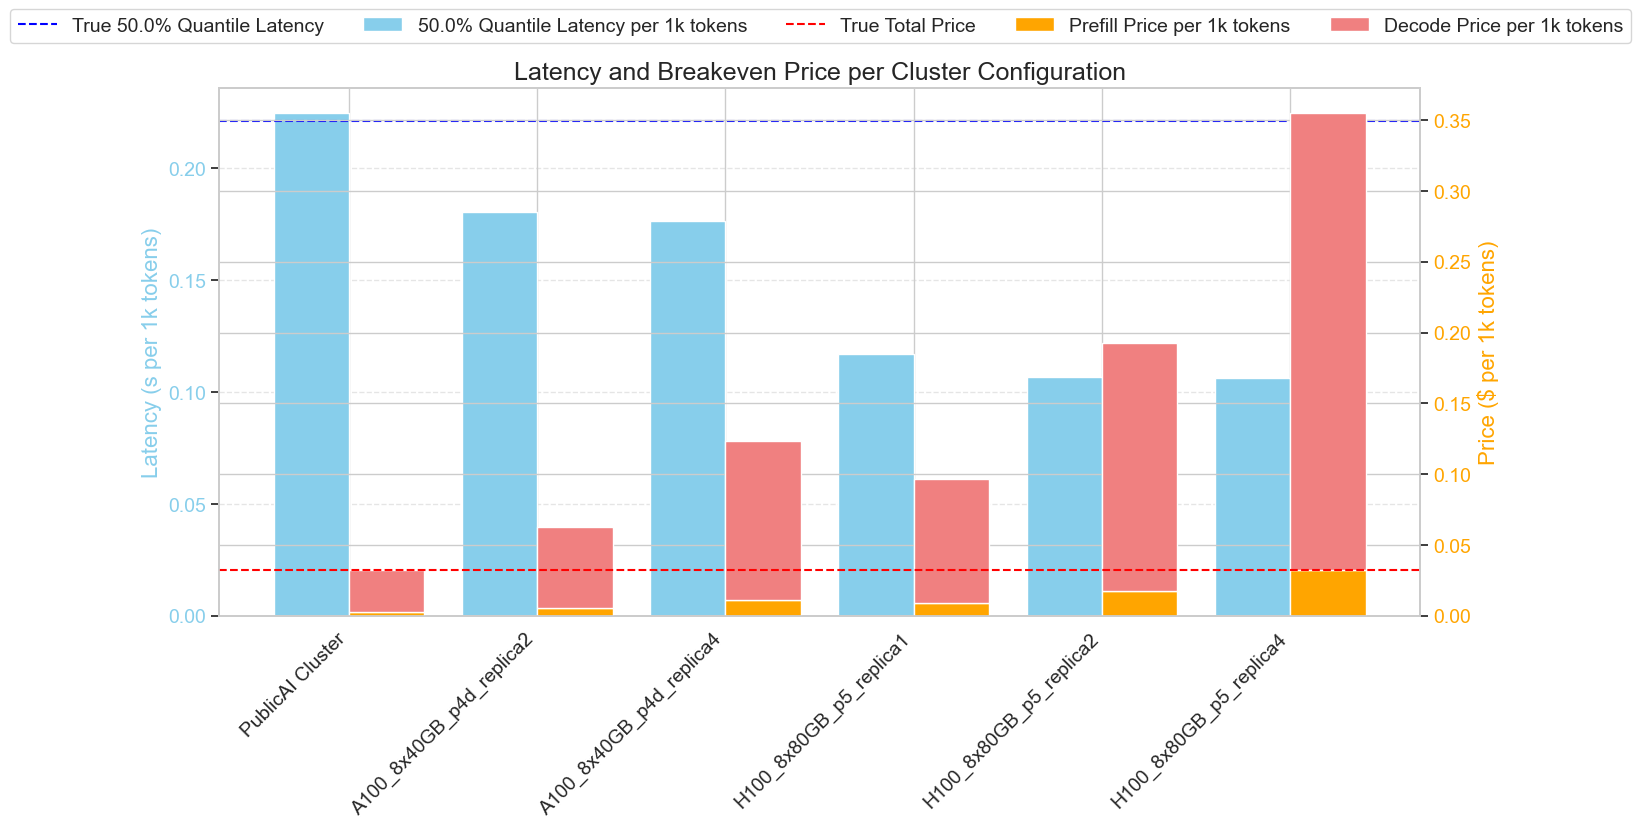

In [111]:
# --- Prepare data (per 1k tokens) ---
cfg_names = [cfg.name for cfg in cluster_cfgs]
latencies_vals = [val for val in latencies]          # per 1k tokens
prefill_prices = [p[0] for p in prices]             # per 1k tokens
decode_prices = [p[1]  for p in prices]             # per 1k tokens

x = np.arange(len(cfg_names))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 8))  # taller figure

# --- Latency bars ---
bars_latency = ax1.bar(
    x - width/2, latencies_vals, width,
    color='skyblue', label=f'{Q*100}% Quantile Latency per 1k tokens'
)
ax1.set_ylabel('Latency (s per 1k tokens)', color='skyblue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='skyblue', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# --- Price bars (stacked) ---
ax2 = ax1.twinx()
bars_prefill = ax2.bar(
    x + width/2, prefill_prices, width,
    color='orange', label='Prefill Price per 1k tokens'
)
bars_decode = ax2.bar(
    x + width/2, decode_prices, width,
    bottom=prefill_prices,
    color='lightcoral', label='Decode Price per 1k tokens'
)
ax2.set_ylabel('Price ($ per 1k tokens)', color='orange', fontsize=16)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=14)

# --- Unified horizontal gridlines ---
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- True value lines (per 1k tokens) ---
ax1.axhline(true_median_latency_per_1K, color='blue', linestyle='--', label=f'True {Q*100}% Quantile Latency')
ax2.axhline((true_prefill_price_1K + true_decode_price_1K), color='red', linestyle='--', label='True Total Price')

# --- X-axis labels ---
ax1.set_xticks(x)
cfg_names[0] = "PublicAI Cluster"
ax1.set_xticklabels(cfg_names, rotation=45, ha='right')

# --- Combined legend above the plot ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    handles1 + handles2, labels1 + labels2,
    loc='upper center', ncol=len(cfg_names), bbox_to_anchor=(0.5, 1.05),
    fontsize=14
)

plt.title("Latency and Breakeven Price per Cluster Configuration", fontsize=18)
plt.tight_layout()
plt.show()


In [98]:
1000*25000/(df_day["total_tokens"].sum()*30)

np.float64(0.011902865268201883)